# Preprocessing for PNR 1z / PNR 2

This notebook loads raw injection/catalog tables, aligns timestamps to UTC, cleans duplicates and outliers,
builds minute-level injection-rate series, and saves processed CSV files.

## 1) Setup and load raw files

In [91]:
from pathlib import Path

import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
import numpy as np
import pandas as pd

RAW_FILES = {
    "df_inj1": Path("../data/PNR_1z/raw/PNR-1z_injection_rates.txt"),
    "df_inj2": Path("../data/PNR_2/raw/PNR-2_injection_rates.txt"),
    "df_cat1": Path("../data/PNR_1z/raw/PNR-1z_microseismicity_catalogue.txt"),
    "df_cat2": Path("../data/PNR_2/raw/PNR-2_microseismicity_catalogue.txt"),
}


def read_raw_table(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=r"\s+", skiprows=[0, 2], header=0)


df_inj1 = read_raw_table(RAW_FILES["df_inj1"])
df_inj2 = read_raw_table(RAW_FILES["df_inj2"])
df_cat1 = read_raw_table(RAW_FILES["df_cat1"])
df_cat2 = read_raw_table(RAW_FILES["df_cat2"])


## 2) Helper functions

In [92]:
def add_datetime_column(
    df,
    out_col="ts",
    set_index=False,
    delete_original=False,
    utc=False,
    floor="s",
):
    candidates = {
        "year": ("year", "Year", "YEAR"),
        "month": ("month", "Month", "MONTH"),
        "day": ("day", "Day", "DAY", "Day "),
        "hour": ("hr", "hour", "Hour", "HR"),
        "minute": ("min", "minute", "Minute", "MIN"),
        "second": ("sec", "second", "Second", "SEC"),
    }

    def _pick(col_names):
        for col in col_names:
            if col in df.columns:
                return col
        raise KeyError(f"None of {col_names} found in dataframe columns")

    picked = {k: _pick(v) for k, v in candidates.items()}

    year = pd.to_numeric(df[picked["year"]], errors="raise").astype("Int64")
    month = pd.to_numeric(df[picked["month"]], errors="raise").astype("Int64")
    day = pd.to_numeric(df[picked["day"]], errors="raise").astype("Int64")
    hour = pd.to_numeric(df[picked["hour"]], errors="raise").astype("Int64")
    minute = pd.to_numeric(df[picked["minute"]], errors="raise").astype("Int64")

    second_raw = pd.to_numeric(df[picked["second"]], errors="raise")
    second_int = np.floor(second_raw).astype("Int64")
    frac = (second_raw - np.floor(second_raw)).fillna(0.0)
    frac_ns = (frac * 1_000_000_000).round().astype("Int64")

    base = pd.to_datetime(
        pd.DataFrame(
            {
                "year": year,
                "month": month,
                "day": day,
                "hour": hour,
                "minute": minute,
                "second": second_int,
            }
        ),
        errors="coerce",
        utc=utc,
    )
    df[out_col] = base + pd.to_timedelta(frac_ns.fillna(0), unit="ns")

    if floor is not None:
        df[out_col] = df[out_col].dt.floor(floor)

    if set_index:
        df.set_index(out_col, inplace=True)

    if delete_original:
        df.drop(columns=list(picked.values()), inplace=True)

    return df


def normalize_catalog(df, lon="Lon", lat="Lat", mag="Mag", depth="Z(km)"):
    rename_map = {}
    if lon in df.columns:
        rename_map[lon] = "Longitude"
    if lat in df.columns:
        rename_map[lat] = "Latitude"
    if mag in df.columns:
        rename_map[mag] = "Magnitude"
    if depth in df.columns:
        rename_map[depth] = "Depth"
    if "Z(m)" in df.columns:
        rename_map["Z(m)"] = "Depth"

    out = df.rename(columns=rename_map) if rename_map else df.copy()
    keep_cols = [c for c in ["Latitude", "Longitude", "Magnitude", "Depth"] if c in out.columns]
    return out[keep_cols]


def convert_index_to_utc(df, local_tz="Europe/London"):
    out = df.sort_index().copy()
    localized = out.index.tz_localize(local_tz, ambiguous="infer", nonexistent="shift_forward")
    out.index = localized.tz_convert("UTC").tz_localize(None)
    return out


def summarize_index_duplicates(df, n=10):
    is_mono = df.index.is_monotonic_increasing
    has_dup = df.index.has_duplicates
    dup_times = df.index[df.index.duplicated()]

    print(f"Is index monotonic increasing: {is_mono}")
    print(f"Does index have duplicates: {has_dup}")
    print(f"Number of duplicate times: {len(dup_times)}")
    if len(dup_times) > 0:
        print(f"Preview of duplicate times: {dup_times[:n]}")


def find_time_gaps(df, min_gap=pd.Timedelta(minutes=1), show_head=5, name=None):
    idx = pd.to_datetime(df.index)
    diff = idx.to_series().diff()
    gaps = diff[diff > min_gap]
    if show_head:
        if name:
            print(f"Gaps in {name} greater than {min_gap}:")
        print(gaps.head(show_head))
    print("Total gaps >", min_gap, ":", len(gaps))
    return gaps


def reindex_minutely(df, start=None, end=None, fill_value=0, index_name="ts"):
    out = df.copy()
    out.index = pd.to_datetime(out.index)
    start = pd.to_datetime(out.index.min() if start is None else start)
    end = pd.to_datetime(out.index.max() if end is None else end)
    new_index = pd.date_range(start=start, end=end, freq="min", name=index_name)
    out = out.reindex(new_index, fill_value=fill_value).fillna(fill_value)
    out.index.name = index_name
    return out


def clip_injection_outliers(df, col="IR_h", lower=0, upper=10):
    out = df.copy()
    mask = (out[col] < lower) | (out[col] > upper)
    out.loc[mask, col] = 0
    return out


## 3) Parse timestamps and normalize columns

In [93]:
df_cat2 = df_cat2.rename(columns={"X": "Lon", "Y": "Lat", "Z(m)": "Depth"})

df_inj1 = add_datetime_column(df_inj1, out_col="ts", set_index=True, delete_original=True)
df_inj2 = add_datetime_column(df_inj2, out_col="ts", set_index=True, delete_original=True)
df_cat1 = add_datetime_column(df_cat1, out_col="ts", set_index=True, delete_original=True)
df_cat2 = add_datetime_column(df_cat2, out_col="ts", set_index=True, delete_original=True)

df_cat1 = normalize_catalog(df_cat1)
df_cat2 = normalize_catalog(df_cat2)

if "injection_rate(m^3/min)" not in df_inj1.columns and "injection_rate(m^3/s)" in df_inj1.columns:
    df_inj1["injection_rate(m^3/min)"] = df_inj1["injection_rate(m^3/s)"] * 60
if "injection_rate(m^3/s)" in df_inj2.columns:
    df_inj2["injection_rate(m^3/min)"] = df_inj2["injection_rate(m^3/s)"] * 60

print(df_inj1.columns)
print(df_inj2.columns)


Index(['injection_rate(m^3/min)'], dtype='object')
Index(['injection_rate(m^3/s)', 'injection_rate(m^3/min)'], dtype='object')


## 4) Convert local BST timestamps to UTC

In [94]:
df_inj1 = convert_index_to_utc(df_inj1)
df_inj2 = convert_index_to_utc(df_inj2)
df_cat2 = convert_index_to_utc(df_cat2)


## 5) Sort, de-duplicate, and inspect gaps

In [95]:
df_inj1 = df_inj1.sort_index().drop_duplicates()
df_inj2 = df_inj2.sort_index().drop_duplicates()
df_cat1 = df_cat1.sort_index().drop_duplicates()
df_cat2 = df_cat2.sort_index().drop_duplicates()

summarize_index_duplicates(df_inj1)
summarize_index_duplicates(df_inj2)

df_inj1 = df_inj1.sort_index().groupby(level=0).mean()
df_inj2 = df_inj2.sort_index().groupby(level=0).mean()

gaps_greater_than_1min1 = find_time_gaps(df_inj1, min_gap=pd.Timedelta(minutes=1), name="df_inj1")
gaps_greater_than_1min2 = find_time_gaps(df_inj2, min_gap=pd.Timedelta(minutes=1), name="df_inj2")

outlier_count_1 = (df_inj1["injection_rate(m^3/min)"] > 50).sum()
outlier_count_2 = (df_inj2["injection_rate(m^3/min)"] > 50).sum()
print(f"Outliers > 50 (df_inj1): {outlier_count_1}")
print(f"Outliers > 50 (df_inj2): {outlier_count_2}")


Is index monotonic increasing: True
Does index have duplicates: True
Number of duplicate times: 48
Preview of duplicate times: DatetimeIndex(['2018-10-19 09:00:52', '2018-10-19 14:16:59',
               '2018-10-22 08:56:53', '2018-10-22 10:05:30',
               '2018-10-22 10:58:39', '2018-10-22 10:58:52',
               '2018-10-22 10:58:54', '2018-10-22 10:59:26',
               '2018-10-22 10:59:51', '2018-10-22 11:00:00'],
              dtype='datetime64[ns]', name='ts', freq=None)
Is index monotonic increasing: True
Does index have duplicates: False
Number of duplicate times: 0
Gaps in df_inj1 greater than 0 days 00:01:00:
ts
2018-10-15 09:12:04   0 days 00:15:33
2018-10-15 09:14:18   0 days 00:01:02
2018-10-15 09:16:11   0 days 00:01:06
2018-10-15 09:23:15   0 days 00:06:33
2018-10-15 09:25:56   0 days 00:02:41
Name: ts, dtype: timedelta64[ns]
Total gaps > 0 days 00:01:00 : 472
Gaps in df_inj2 greater than 0 days 00:01:00:
ts
2019-08-13 16:30:59   0 days 01:00:42
2019-08-15 08:

## 6) Resample to 1-minute, fill missing values, and clip outliers

In [96]:
df_inj1_m = df_inj1.resample("min").mean().rename(columns={"injection_rate(m^3/min)": "IR_h"})
df_inj2_m = df_inj2.resample("min").mean().rename(columns={"injection_rate(m^3/min)": "IR_h"})

s_cat1, e_cat1 = df_cat1.index.min(), df_cat1.index.max()
s_cat2, e_cat2 = df_cat2.index.min(), df_cat2.index.max()
print(f"df_cat1 range: {s_cat1} -> {e_cat1}")
print(f"df_cat2 range: {s_cat2} -> {e_cat2}")

df_inj1_m = reindex_minutely(df_inj1_m, end=e_cat1 + pd.Timedelta(hours=1), fill_value=0)
df_inj2_m = reindex_minutely(df_inj2_m, end=e_cat2 + pd.Timedelta(hours=1), fill_value=0)

df_inj1_m = clip_injection_outliers(df_inj1_m, col="IR_h", lower=0, upper=10)
df_inj2_m = clip_injection_outliers(df_inj2_m, col="IR_h", lower=0, upper=10)


df_cat1 range: 2018-10-15 13:24:02 -> 2018-12-18 12:30:56
df_cat2 range: 2019-08-13 19:38:56 -> 2019-10-02 04:27:34


## 7) Quick checks

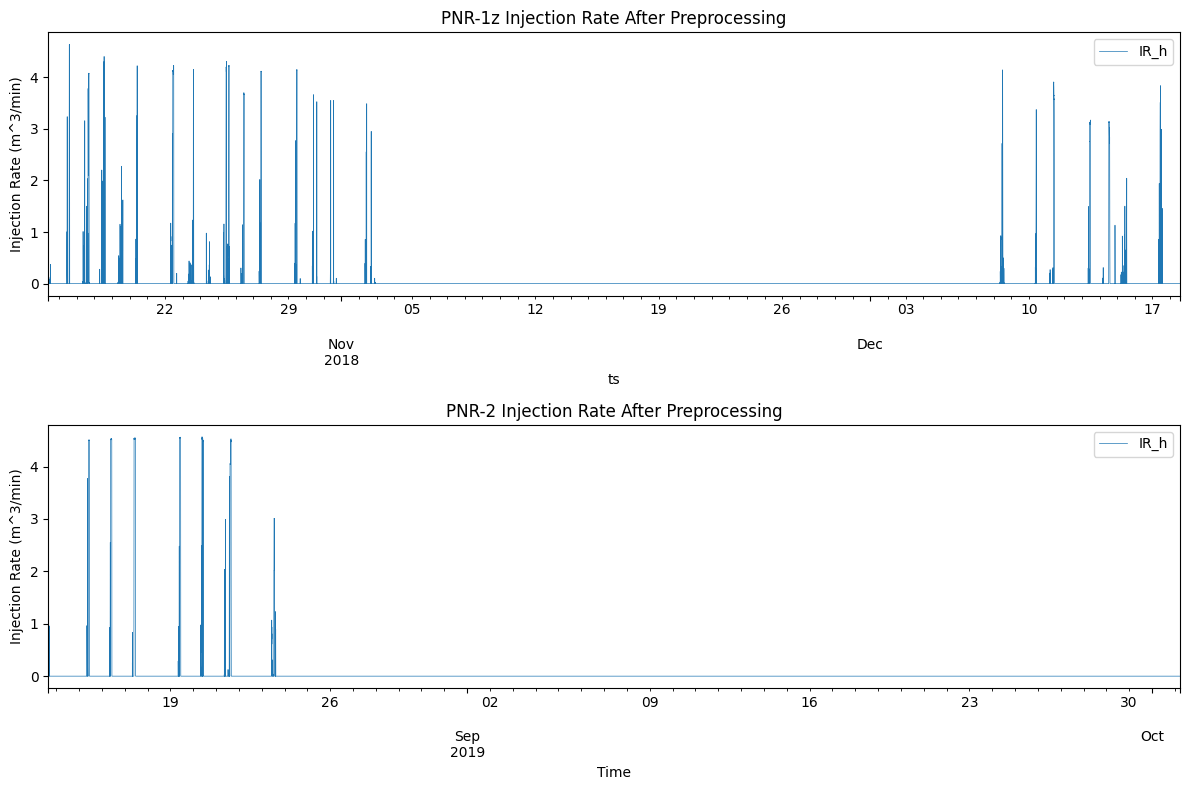

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
df_inj1_m.plot(y="IR_h", ax=axes[0], title="PNR-1z Injection Rate After Preprocessing", linewidth=0.5)
df_inj2_m.plot(y="IR_h", ax=axes[1], title="PNR-2 Injection Rate After Preprocessing", linewidth=0.5)
axes[0].set_ylabel("Injection Rate (m^3/min)")
axes[1].set_ylabel("Injection Rate (m^3/min)")
axes[1].set_xlabel("Time")
plt.tight_layout()


## 8) Save processed outputs

In [98]:
df_cat1.to_csv("../data/PNR_1z/raw/PNR_1z_catalog.csv")
df_cat2.to_csv("../data/PNR_2/raw/PNR_2_catalog.csv")

df_inj1.to_csv("../data/PNR_1z/raw/PNR-1z_injection_rates.csv")
df_inj2.to_csv("../data/PNR_2/raw/PNR-2_injection_rates.csv")

df_inj1_m.to_csv("../data/PNR_1z/raw/PNR_1z_injection_rate_per_min.csv")
df_inj2_m.to_csv("../data/PNR_2/raw/PNR_2_injection_rate_per_min.csv")


In [99]:
print("Saved files:")
print("- ../data/PNR_1z/raw/PNR_1z_catalog.csv")
print("- ../data/PNR_2/raw/PNR_2_catalog.csv")
print("- ../data/PNR_1z/raw/PNR-1z_injection_rates.csv")
print("- ../data/PNR_2/raw/PNR-2_injection_rates.csv")
print("- ../data/PNR_1z/raw/PNR_1z_injection_rate_per_min.csv")
print("- ../data/PNR_2/raw/PNR_2_injection_rate_per_min.csv")


Saved files:
- ../data/PNR_1z/raw/PNR_1z_catalog.csv
- ../data/PNR_2/raw/PNR_2_catalog.csv
- ../data/PNR_1z/raw/PNR-1z_injection_rates.csv
- ../data/PNR_2/raw/PNR-2_injection_rates.csv
- ../data/PNR_1z/raw/PNR_1z_injection_rate_per_min.csv
- ../data/PNR_2/raw/PNR_2_injection_rate_per_min.csv


## 9) Visualization Analysis


### 9.1 Peak detection on minute-level injection series


PNR-1z peak window preview:
                              left_base          right_base
ts                                                         
2018-10-16 10:52:00 2018-10-16 10:47:00 2018-10-16 10:57:00
2018-10-16 13:52:00 2018-10-16 13:27:00 2018-10-16 14:07:00
2018-10-17 10:44:00 2018-10-17 10:40:00 2018-10-17 10:48:00
2018-10-17 13:31:00 2018-10-17 13:30:00 2018-10-17 13:32:00
2018-10-17 14:26:00 2018-10-17 14:23:00 2018-10-17 14:27:00
2018-10-17 15:19:00 2018-10-17 15:06:00 2018-10-17 15:36:00
2018-10-17 16:19:00 2018-10-17 15:06:00 2018-10-17 16:36:00
2018-10-18 09:57:00 2018-10-18 09:54:00 2018-10-18 10:01:00
2018-10-18 11:24:00 2018-10-18 11:21:00 2018-10-18 11:25:00
2018-10-18 12:47:00 2018-10-18 12:42:00 2018-10-18 12:48:00
PNR-2 peak window preview:
                              left_base          right_base
ts                                                         
2019-08-15 09:01:00 2019-08-15 08:56:00 2019-08-15 09:04:00
2019-08-15 10:30:00 2019-08-15 09:39:00 2019-

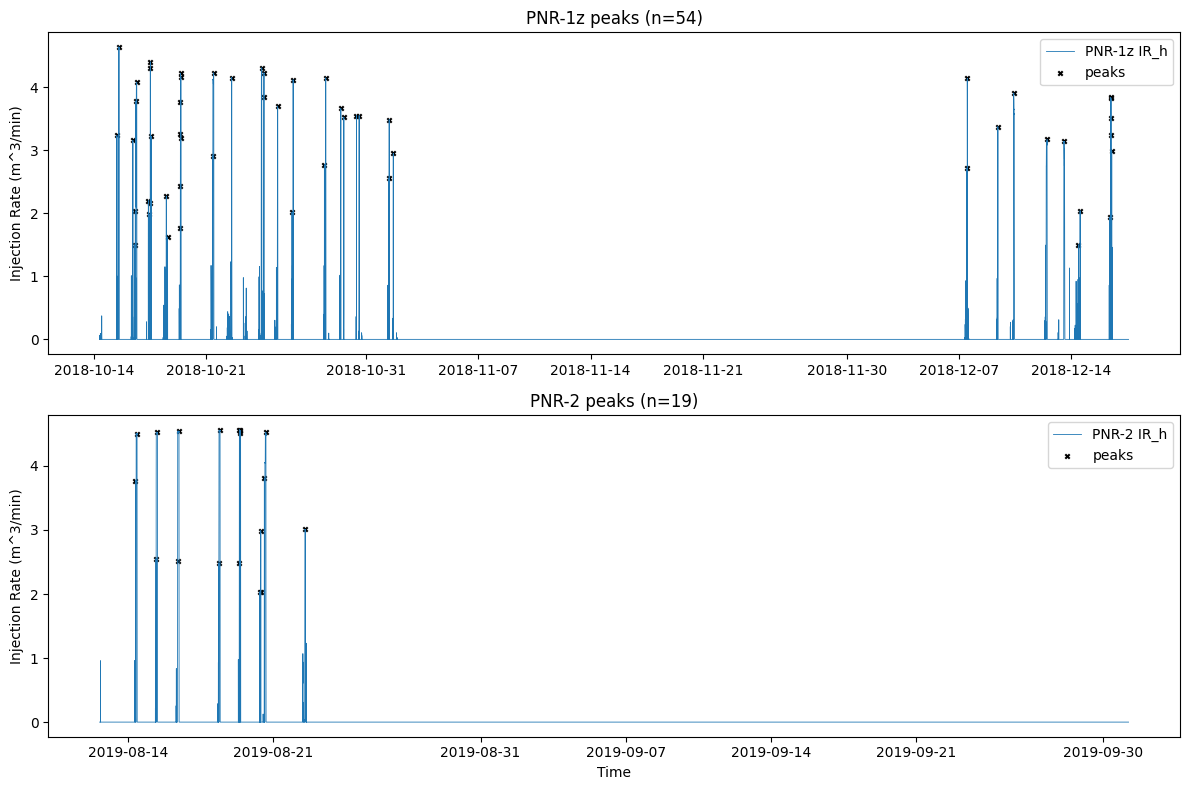

In [100]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def detect_peaks_in_series(df, col='IR_h', prominence=0.5, distance=5, **kwargs):
    values = df[col].to_numpy()
    idx, props = find_peaks(values, prominence=prominence, distance=distance, **kwargs)

    peak_df = pd.DataFrame(
        {
            'value': df[col].iloc[idx].to_numpy(),
            'left_base': df.index[props.get('left_bases', np.array([], dtype=int))],
            'right_base': df.index[props.get('right_bases', np.array([], dtype=int))],
        },
        index=pd.Index(df.index[idx], name='ts'),
    )
    return peak_df, props


peak_cfg = {'height': 1.5, 'prominence': 0.5, 'distance': 5}
peak_inj1, props_inj1 = detect_peaks_in_series(df_inj1_m, col='IR_h', **peak_cfg)
peak_inj2, props_inj2 = detect_peaks_in_series(df_inj2_m, col='IR_h', **peak_cfg)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
axes[0].plot(df_inj1_m.index, df_inj1_m['IR_h'], linewidth=0.6, label='PNR-1z IR_h')
axes[0].scatter(peak_inj1.index, peak_inj1['value'], color='k', s=10, marker='x', label='peaks')
axes[0].set_title(f'PNR-1z peaks (n={len(peak_inj1)})')
axes[0].set_ylabel('Injection Rate (m^3/min)')
axes[0].legend()

axes[1].plot(df_inj2_m.index, df_inj2_m['IR_h'], linewidth=0.6, label='PNR-2 IR_h')
axes[1].scatter(peak_inj2.index, peak_inj2['value'], color='k', s=10, marker='x', label='peaks')
axes[1].set_title(f'PNR-2 peaks (n={len(peak_inj2)})')
axes[1].set_ylabel('Injection Rate (m^3/min)')
axes[1].set_xlabel('Time')
axes[1].legend()
plt.tight_layout()

print('PNR-1z peak window preview:')
print(peak_inj1[['left_base', 'right_base']].head(10))
print('PNR-2 peak window preview:')
print(peak_inj2[['left_base', 'right_base']].head(10))


### 9.2 Injection vs earthquake-count comparison


(<Figure size 1200x500 with 2 Axes>,
 <Axes: title={'center': 'Injection vs EQ count (dt=1min, window=1min)'}, xlabel='Time', ylabel='Injection rate (m^3/min)'>,
 <Axes: ylabel='Earthquakes in past 1min'>,
                      injection_rate(m^3/s)  IR_h  eq_count
 ts                                                        
 2019-08-15 06:00:00                    0.0   0.0       0.0
 2019-08-15 06:01:00                    0.0   0.0       0.0
 2019-08-15 06:02:00                    0.0   0.0       0.0
 2019-08-15 06:03:00                    0.0   0.0       0.0
 2019-08-15 06:04:00                    0.0   0.0       0.0
 ...                                    ...   ...       ...
 2019-08-15 18:55:00                    0.0   0.0       0.0
 2019-08-15 18:56:00                    0.0   0.0       0.0
 2019-08-15 18:57:00                    0.0   0.0       2.0
 2019-08-15 18:58:00                    0.0   0.0       2.0
 2019-08-15 18:59:00                    0.0   0.0       0.0
 
 [780 rows x

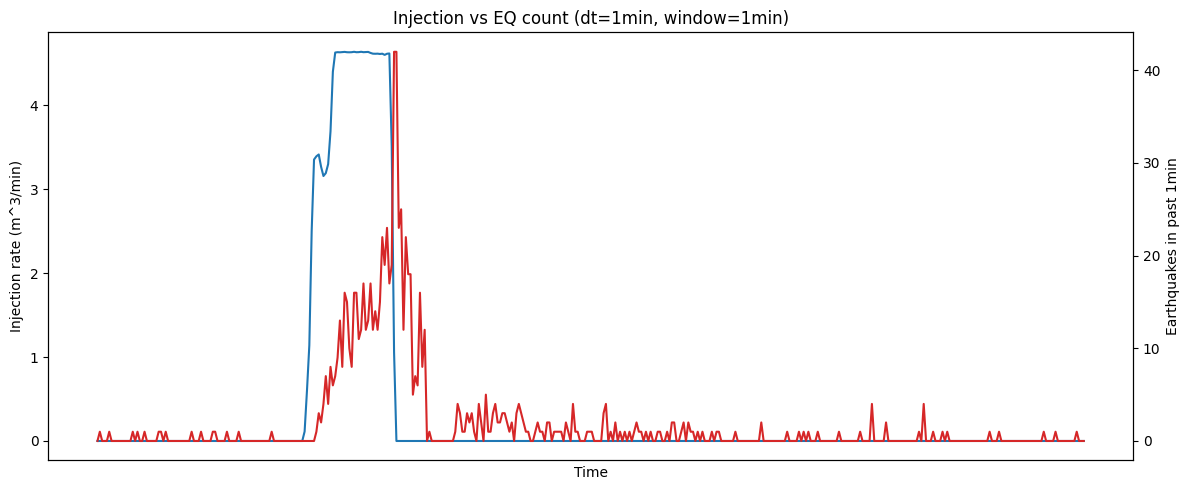

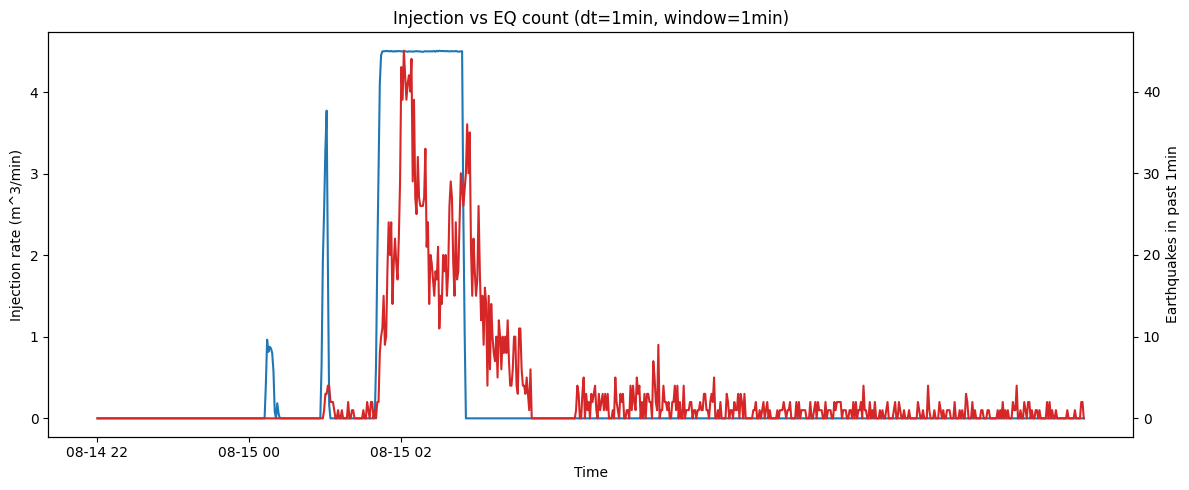

In [101]:
def plot_injection_vs_eq(
    df_inj,
    df_cat,
    start=None,
    end=None,
    dt='1min',
    win='1min',
    inj_col='IR_h',
    eq_col_name='eq_count',
    fill_value=0,
    figsize=(12, 5),
):
    inj = df_inj.loc[start:end].copy()
    eq = df_cat.loc[start:end].copy()

    inj_dt = inj.resample(dt).mean()
    eq_cnt_dt = eq.resample(dt).size().to_frame(eq_col_name)

    try:
        eq_cnt_win = eq_cnt_dt[eq_col_name].rolling(win).sum()
    except Exception:
        periods = max(1, int(pd.Timedelta(win) / pd.Timedelta(dt)))
        eq_cnt_win = eq_cnt_dt[eq_col_name].rolling(periods, min_periods=1).sum()

    df_plot = inj_dt.join(eq_cnt_dt, how='outer').fillna(fill_value)
    eq_cnt_win = eq_cnt_win.reindex(df_plot.index, fill_value=0)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(df_plot.index, df_plot[inj_col], color='tab:blue', label='injection')
    ax1.set_ylabel('Injection rate (m^3/min)')
    ax1.set_xlabel('Time')

    ax2 = ax1.twinx()
    ax2.plot(df_plot.index, eq_cnt_win, color='tab:red', label=f'events ({win})')
    ax2.set_ylabel(f'Earthquakes in past {win}')

    ax1.set_title(f'Injection vs EQ count (dt={dt}, window={win})')
    fig.tight_layout()
    return fig, ax1, ax2, df_plot


plot_injection_vs_eq(
    df_inj1_m,
    df_cat1,
    start='2018-10-16 12:00:00',
    end='2018-10-16 18:59:59',
)

plot_injection_vs_eq(
    df_inj2_m,
    df_cat2,
    start='2019-08-15 06:00:00',
    end='2019-08-15 18:59:59',
)


### 9.3 Seismicity-rate and magnitude distributions


PNR-2 events with M > -2: 54152


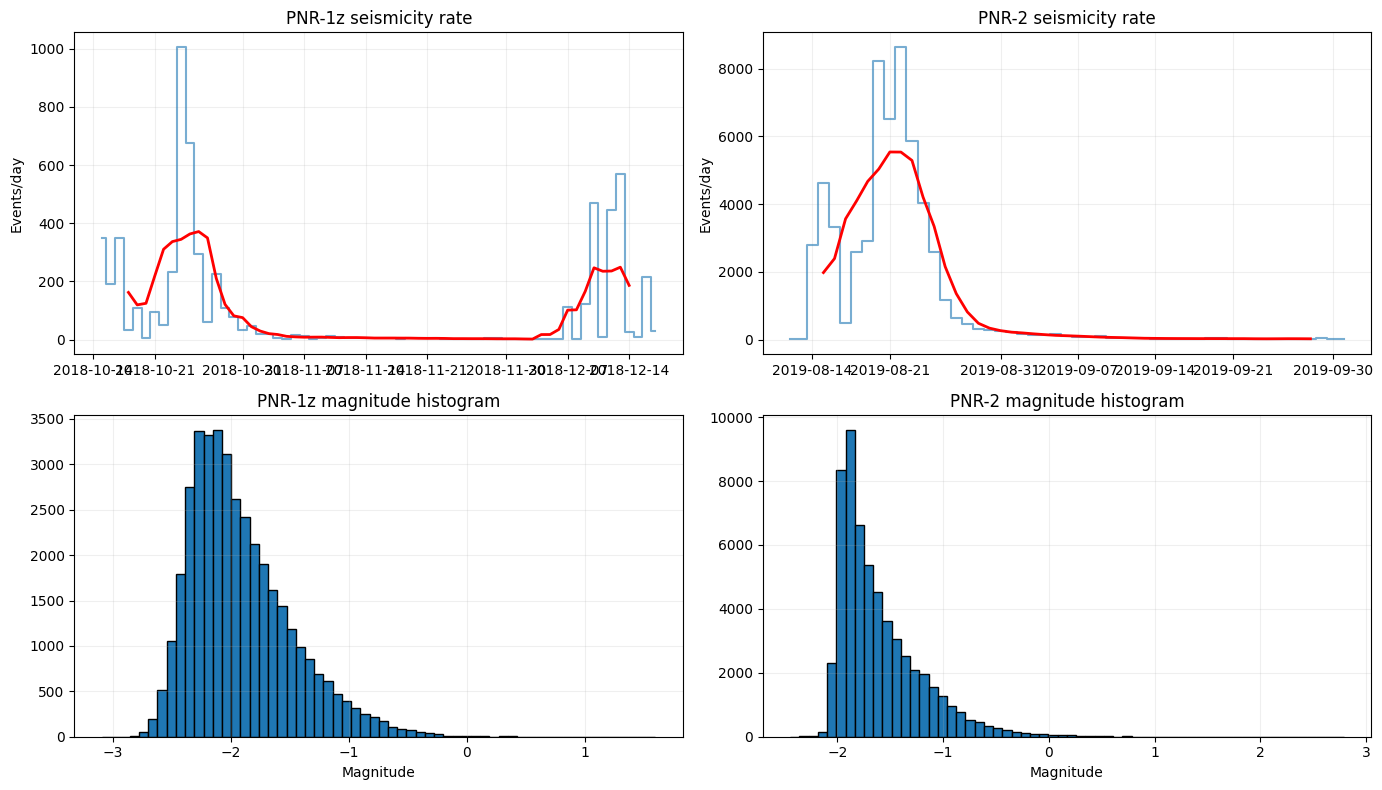

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

freq = '1D'
window = 7

cat1_counts = df_cat1[df_cat1['Magnitude'] >= -1.5].resample(freq).size()
cat1_smoothed = cat1_counts.rolling(window=window, center=True).mean()
axes[0, 0].plot(cat1_counts.index, cat1_counts, drawstyle='steps-mid', alpha=0.6)
axes[0, 0].plot(cat1_smoothed.index, cat1_smoothed, color='red', linewidth=2)
axes[0, 0].set_title('PNR-1z seismicity rate')
axes[0, 0].set_ylabel('Events/day')

cat2_counts = df_cat2.resample(freq).size()
cat2_smoothed = cat2_counts.rolling(window=window, center=True).mean()
axes[0, 1].plot(cat2_counts.index, cat2_counts, drawstyle='steps-mid', alpha=0.6)
axes[0, 1].plot(cat2_smoothed.index, cat2_smoothed, color='red', linewidth=2)
axes[0, 1].set_title('PNR-2 seismicity rate')
axes[0, 1].set_ylabel('Events/day')

axes[1, 0].hist(df_cat1['Magnitude'].dropna(), bins=60, edgecolor='black')
axes[1, 0].set_title('PNR-1z magnitude histogram')
axes[1, 0].set_xlabel('Magnitude')

axes[1, 1].hist(df_cat2['Magnitude'].dropna(), bins=60, edgecolor='black')
axes[1, 1].set_title('PNR-2 magnitude histogram')
axes[1, 1].set_xlabel('Magnitude')

for ax in axes.ravel():
    ax.grid(True, alpha=0.2)

plt.tight_layout()
print(f"PNR-2 events with M > -2: {(df_cat2['Magnitude'] > -2).sum()}")


### 9.4 Hourly/minutely diagnostics


Last nonzero hourly injection in PNR-2: 2019-08-23 14:00:00


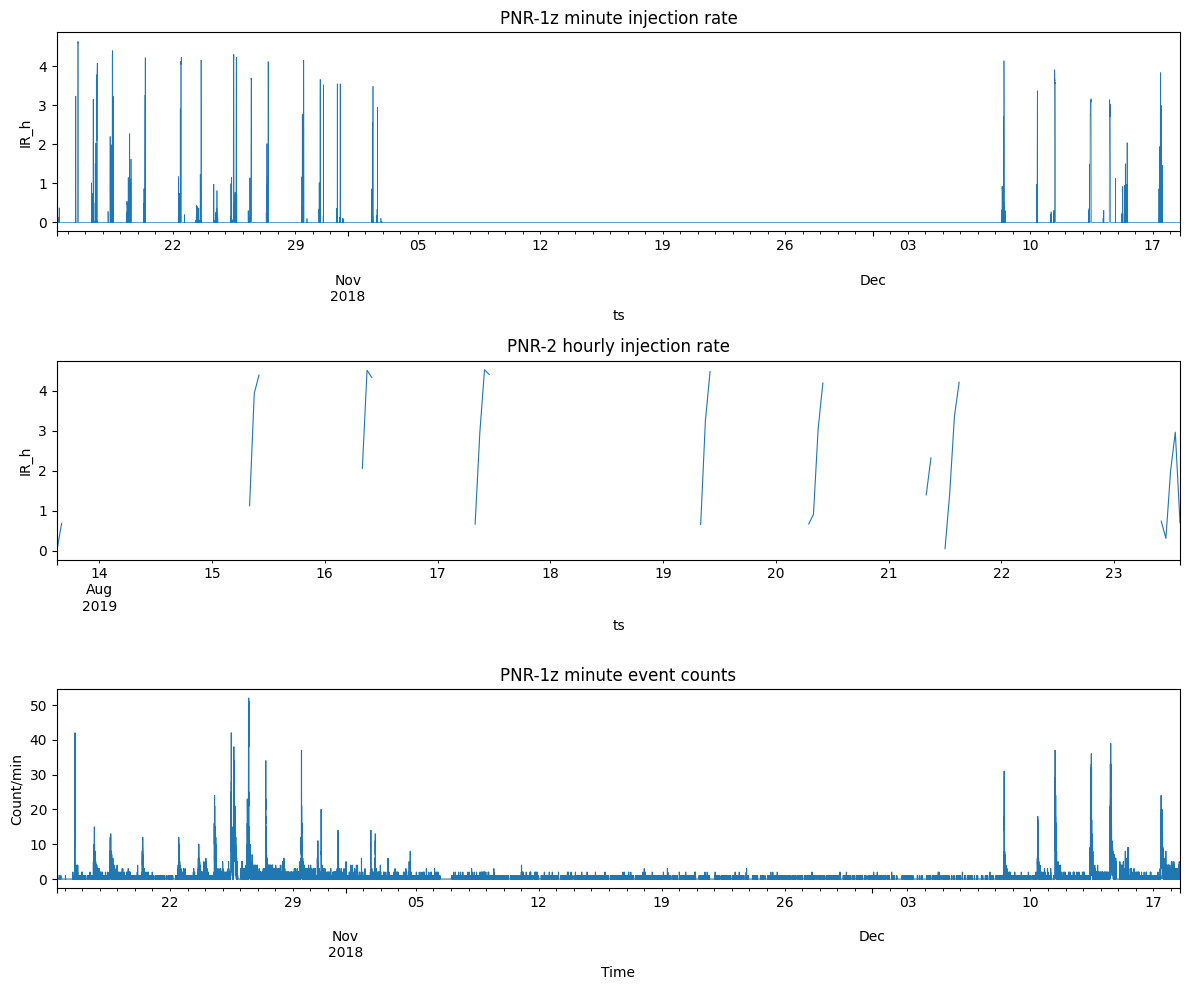

In [103]:
df_inj1_h = df_inj1.resample('h').mean().rename(columns={'injection_rate(m^3/min)': 'IR_h'})
df_inj2_h = df_inj2.resample('h').mean().rename(columns={'injection_rate(m^3/min)': 'IR_h'})

event_counts_min = df_cat1.resample('min').size()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
df_inj1_m['IR_h'].plot(ax=axes[0], linewidth=0.5, title='PNR-1z minute injection rate')
axes[0].set_ylabel('IR_h')

df_inj2_h['IR_h'].plot(ax=axes[1], linewidth=0.8, title='PNR-2 hourly injection rate')
axes[1].set_ylabel('IR_h')

event_counts_min.plot(ax=axes[2], linewidth=0.8, title='PNR-1z minute event counts')
axes[2].set_ylabel('Count/min')
axes[2].set_xlabel('Time')

plt.tight_layout()

nonzero = df_inj2_h[df_inj2_h['IR_h'] != 0]
last_nonzero_date = None if nonzero.empty else nonzero.index.max()
print('Last nonzero hourly injection in PNR-2:', last_nonzero_date)


### 9.5 Mc estimation and arrival-time feature preview


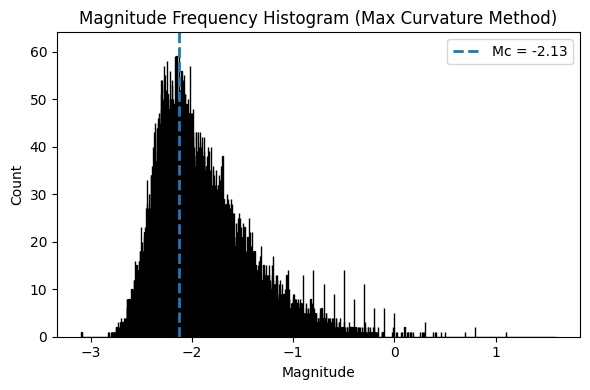

Estimated Mc = -2.13
arrival_times preview: [ 1.40055556  4.53333333  6.81777778 13.11444444 22.905      23.07166667
 23.12194444 23.18527778 23.20888889 23.20916667]


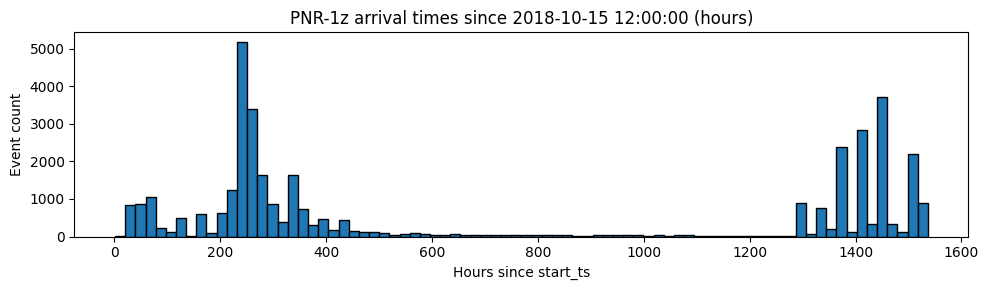

In [104]:
from src.data.preprocessing import estimate_mc_max_curvature

mags = df_cat1['Magnitude'].dropna().values
mc, bin_centers, counts = estimate_mc_max_curvature(mags, bin_width=0.001, plot=True)
print(f'Estimated Mc = {mc:.2f}')

start_ts = pd.Timestamp('2018-10-15 12:00:00')
arrival_times = ((df_cat1.index.to_series().sort_values() - start_ts) / pd.Timedelta('1h')).dropna().to_numpy()

plt.figure(figsize=(10, 3))
plt.hist(arrival_times, bins=80, edgecolor='black')
plt.title('PNR-1z arrival times since 2018-10-15 12:00:00 (hours)')
plt.xlabel('Hours since start_ts')
plt.ylabel('Event count')
plt.tight_layout()

print('arrival_times preview:', arrival_times[:10])
